Diabetes Prediction

Goal: Build a simple machine learning model to predict whether a patient has diabetes based on diagnostic measurements.

Dataset:diabetes.csv  
- 768 samples  
- 8 medical features + target (Outcome: 0 = No diabetes, 1 = Diabetes)  

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, ConfusionMatrixDisplay, classification_report)
sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the dataset

In [2]:
data=pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
data.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [5]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

# Target distribution
Count the percentage of people that are diabetic and non-diabetic

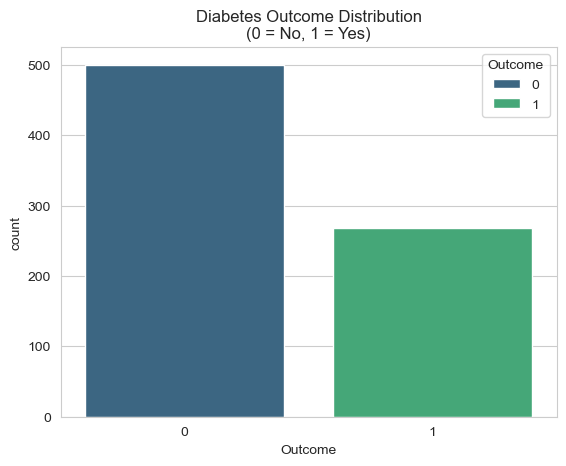

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [6]:
sns.countplot(x="Outcome", data=data, palette="viridis",hue='Outcome')
plt.title("Diabetes Outcome Distribution\n(0 = No, 1 = Yes)")
plt.show()
print(data["Outcome"].value_counts(normalize=True) * 100)

# Observation
- 65% are non-diabetic while 35% are diabetic

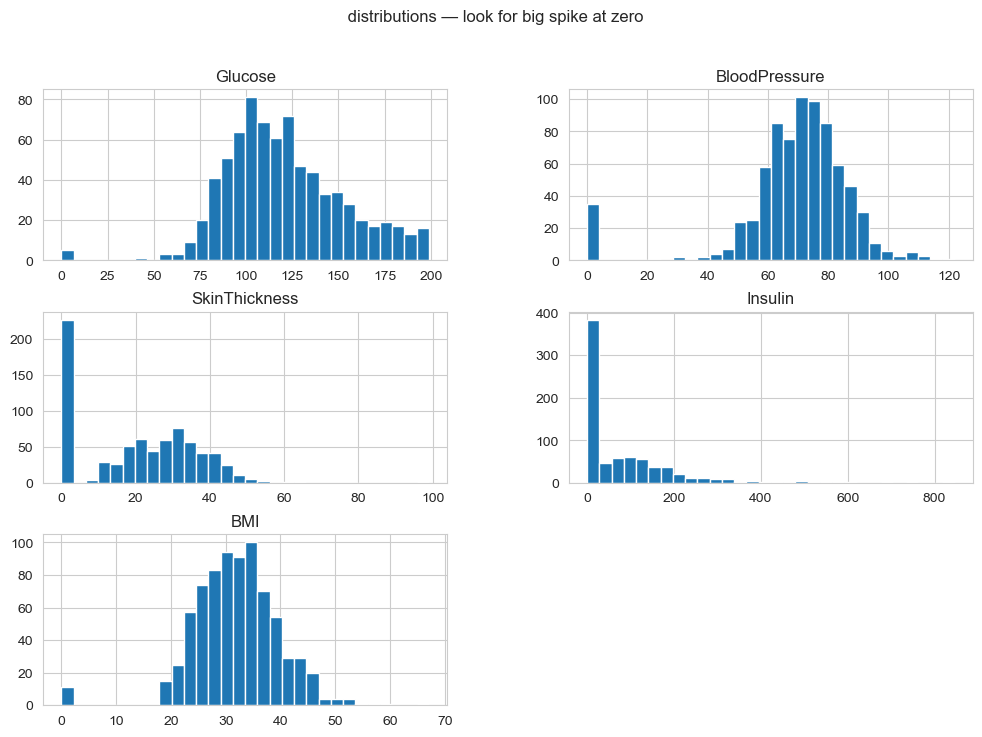

In [7]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

data[cols].hist(bins=30, figsize=(12, 8))
plt.suptitle(" distributions — look for big spike at zero")
plt.show()

In [8]:
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    med_0 = data[data.Outcome == 0][col].median()
    med_1 = data[data.Outcome == 1][col].median()
    
    data.loc[(data[col] == 0) & (data.Outcome == 0), col] = med_0
    data.loc[(data[col] == 0) & (data.Outcome == 1), col] = med_1
    
    print(f"{col:15} → non-diabetic median {med_0:.1f} | diabetic median {med_1:.1f}")

Glucose         → non-diabetic median 107.0 | diabetic median 140.0
BloodPressure   → non-diabetic median 70.0 | diabetic median 74.0
SkinThickness   → non-diabetic median 21.0 | diabetic median 27.0
Insulin         → non-diabetic median 39.0 | diabetic median 0.0
BMI             → non-diabetic median 30.1 | diabetic median 34.2


# observation
- Glucose,BloodPressure,SkinThickness,Insulin,BMI have zero values so we replace those zeros with the median per class

## 5. Feature Selection
- We drop Pregnancies column

In [9]:
data.drop('Pregnancies',axis=1,inplace=True)

In [10]:
x= data.drop("Outcome",axis=1)
y = data["Outcome"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

# Scale features

In [11]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

## 6. Create Logistic Regression model

In [12]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(x_train_scaled, y_train)

y_pred = lr.predict(x_test_scaled)

# Evaluation of the model

In [13]:
print("Accuracy :",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall :",recall_score(y_test, y_pred))
print("F1 : ",f1_score(y_test, y_pred))

Accuracy : 0.7748917748917749
Precision: 0.7377049180327869
Recall : 0.5555555555555556
F1 :  0.6338028169014085


In [14]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       150
           1       0.74      0.56      0.63        81

    accuracy                           0.77       231
   macro avg       0.76      0.72      0.74       231
weighted avg       0.77      0.77      0.77       231



## What I actually achieved & what went well

- I spotted the impossible zeros in Glucose, BMI, BloodPressure etc.
- Replaced zeros with group medians (different value for diabetic vs non-diabetic) instead of dropping rows
- Checked confusion matrix and recall (not only accuracy) — important since missing diabetics is a big problem
- Got consistent 77–80% accuracy with simple logistic regression
I’m happy I took time on cleaning and didn’t just run the model blindly. Learned that good data prep matters way more than fancy algorithms on small datasets like this.